In [ ]:
import numpy as np
import os

# Define paths to your folders
high_risk_dir = '/content/drive/MyDrive/A_RESEARCH_TRAINING/SHAPELETS/High_r_stacked_rc_8.npy'
low_risk_dir =  '/content/drive/MyDrive/A_RESEARCH_TRAINING/SHAPELETS/Low_r_stacked_rc_8.npy'

# # Load .npy files and create labels
# def load_data(folder_path, label):
#     samples=[]
#     data = np.load(folder_path,allow_pickle=True)
#     for sample in data:
#       samples.append(sample)  # Iterate over axis=0 (37 or 113 samples)

#     return np.array(samples), np.full(len(samples), label)

# Load .npy files and create labels
def load_data(folder_path, label):
    # Load the data from the .npy file. It's likely an array of (7, 128) object arrays.
    data_loaded = np.load(folder_path, allow_pickle=True)

    # Convert each individual sample (which is expected to be a 2D array-like structure)
    # into a proper NumPy array with 'float64' dtype.
    # np.asarray is flexible and will convert lists, tuples, or existing arrays.
    # The .astype(np.float64) ensures numerical type even if source elements were strings or other objects.
    numeric_samples = [np.asarray(sample, dtype=np.float64) for sample in data_loaded]

    # Now, stack these correctly typed 2D arrays into a single 3D numeric array.
    # This assumes all individual samples (e.g., each (7, 128) array) have consistent dimensions.
    try:
        stacked_numeric_data = np.stack(numeric_samples)
    except ValueError as e:
        print(f"Error stacking data from {folder_path}: {e}")
        print("This indicates that the individual samples loaded from your .npy file")
        print("do NOT all have a consistent shape (e.g., some are (7, 128) and others are different).")
        print("You will need to preprocess your raw data to ensure uniform shapes before saving or loading.")
        raise e # Re-raise the error to stop execution if shapes are inconsistent.

    return stacked_numeric_data, np.full(len(data_loaded), label)


# Load high-risk samples (label=1)
X_high, y_high = load_data(high_risk_dir, 1)

# Load low-risk samples (label=0)
X_low, y_low = load_data(low_risk_dir, 0)

# Combine datasets
X = np.concatenate((X_high, X_low), axis=0)
y = np.concatenate((y_high, y_low), axis=0)


# --- ADD THESE LINES TO DIAGNOSE ---
print(f"X dtype: {X.dtype}")
print(f"X shape: {X.shape}")
if X.shape[0] > 0: # Check if X is not empty before trying to access elements
    print(f"Shape of first sample (X[0]): {X[0].shape}")
    print(f"Dtype of first sample (X[0].dtype): {X[0].dtype}")
# -----------------------------------

X dtype: float64
X shape: (150, 7, 128)
Shape of first sample (X[0]): (7, 128)
Dtype of first sample (X[0].dtype): float64


In [ ]:
# see the shape of X
print(X.shape)


(150, 7, 128)


In [ ]:
#check if there's 7th column
print(X[:,:,7].shape)

(150, 7)


In [ ]:
# get a glipse of X
print(X)

[[[7.27830754e+01 7.22083023e+01 7.16979465e+01 ... 7.46460796e+01
   7.40117468e+01 7.33855158e+01]
  [6.25170000e+00 6.25648844e+00 6.25678780e+00 ... 6.25191769e+00
   6.24368960e+00 6.25170000e+00]
  [1.09859155e+01 1.09859155e+01 1.09859155e+01 ... 9.01408451e+00
   9.85915493e+00 9.01408451e+00]
  ...
  [2.21408273e-01 2.16986941e-01 2.13061127e-01 ... 2.35739074e-01
   2.30859591e-01 2.26042430e-01]
  [3.74431257e-01 3.75328175e-01 3.75456847e-01 ... 3.74362809e-01
   3.72973376e-01 3.74431220e-01]
  [7.58231417e-02 7.58231417e-02 7.58231417e-02 ... 6.19561306e-02
   6.78991354e-02 6.19561306e-02]]

 [[7.54603620e+01 7.48564338e+01 7.41695709e+01 ... 7.74728230e+01
   7.67550431e+01 7.60843683e+01]
  [6.97810000e+00 6.98772633e+00 6.98450628e+00 ... 6.97557537e+00
   6.97482854e+00 6.97810000e+00]
  [1.09859155e+01 1.09859155e+01 1.09859155e+01 ... 9.01408451e+00
   9.85915493e+00 9.01408451e+00]
  ...
  [2.64872713e-01 2.59621163e-01 2.53648443e-01 ... 2.82372374e-01
   2.76130

In [ ]:
#out of the 7 dimensions of the 3d np.array, take only the 4th,5th and 6th dimensions
# 4th = Pressure
# 5th = diameter
# 6th = velocity

 # run once as X is used again
# in range 4 : 7
X=X[:,4:7,:]
print(X.shape)

(150, 3, 128)


In [ ]:
y.shape

(150,)

In [ ]:
print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


In [ ]:
!pip install cupy-cuda11x  # replace 11x with your CUDA version
import cupy as cp
np = cp  # monkey patch so rest of the code remains unchanged


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.7/99.7 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 4.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
from sklearn.metrics import mutual_info_score
from numba import njit
from random import sample
import pandas as pd

@njit(fastmath=True)
def z_normalize(ts):
    mean = np.mean(ts)
    std = np.std(ts)
    return (ts - mean) / std if std > 0 else ts - mean

@njit(fastmath=True)
def z_normalize_2d(series):
    # Normalize each row (dim) independently
    dims, length = series.shape
    normed = np.empty_like(series)
    for d in range(dims):
        mean = np.mean(series[d])
        std = np.std(series[d])
        if std > 0:
            normed[d] = (series[d] - mean) / std
        else:
            normed[d] = series[d] - mean
    return normed

@njit(fastmath=True)
def sliding_distance(series, shapelet):
    """
    Compute the minimum z-normalized Euclidean distance between a
    multivariate shapelet and all subsequences of a time series.
    """
    # slied argo minimum distance yemifelegelen nw
    dims, length = series.shape
    _, s_len = shapelet.shape
    min_dist = np.inf

    norm_shapelet = z_normalize_2d(shapelet)

    for start in range(length - s_len + 1):
        subseq = series[:, start:start + s_len]
        norm_subseq = z_normalize_2d(subseq)

        dist = 0.0
        for d in range(dims):
            for t in range(s_len):
                diff = norm_subseq[d, t] - norm_shapelet[d, t]
                dist += diff * diff

        dist = np.sqrt(dist)
        if dist < min_dist:
            min_dist = dist

    return min_dist

def extract_shapelets(X, y, shapelet_lengths, num_shapelets_per_length,
                      stride_ratio=0.5, max_candidates_per_length=300,
                      n_bins=20, random_state = 42):
    n_samples, dims, series_length = X.shape
    scored = []
    rng = np.random.default_rng(random_state)

    for s_len in shapelet_lengths:
        stride = max(1, int(s_len * stride_ratio))
        candidates = []

        # Generate candidates with stride
        # it's just cutting out possible shapelets frommn the entire length
        for i in range(n_samples):
            for start in range(0, series_length - s_len + 1, stride):
                shp = X[i, :, start:start + s_len]
                candidates.append((shp, i, start))

        # Optional: limit number of candidates
        if len(candidates) > max_candidates_per_length:
            indices = rng.choice(len(candidates), max_candidates_per_length, replace=False)
            candidates = [candidates[i] for i in indices]

        # Score candidates
        for shp, i, start in candidates:
            dists = np.array([sliding_distance(X[j], shp) for j in range(n_samples)])

            # Bin distances (faster than checking every unique value)
            bins = np.histogram_bin_edges(dists, bins=n_bins)
            binned = np.digitize(dists, bins)
            # ye andun shapelet difference with all samples nw histogram miseraw for easier computation of MI
            mi = mutual_info_score(y, binned)
            scored.append((mi, shp,start))

    # Sort by MI and keep top shapelets
    scored.sort(key=lambda x: x[0], reverse=True)
    top_k = num_shapelets_per_length * len(shapelet_lengths)
    selected = scored[:top_k]
    print([start for _,shp,start in selected])
    global needed_list
    needed_list = [start for _,shp,start in selected]
    return [shp for _, shp,start in selected]

def transform_with_shapelets(X, shapelets):
    n_samples = X.shape[0]
    n_shapelets = len(shapelets)
    features = np.zeros((n_samples, n_shapelets))

    for i in range(n_samples):
        for j, shp in enumerate(shapelets):
            features[i, j] = sliding_distance(X[i], shp)
    # col_names = [f"len{shp.shape[1]}_{j}" for j, shp in enumerate(shapelets)]

    return features #pd.DataFrame(features,columns=col_names)


In [ ]:

# Extract shapelets of lengths 10 and 20, 5 per length
shapelets = extract_shapelets(X, y, shapelet_lengths=[4,8,16,32,64], num_shapelets_per_length=5,random_state=42) # remaining 16,32,64

# Transform data
features = transform_with_shapelets(X, shapelets)
print("Transformed feature matrix shape:", features.shape)



[0, 16, 44, 0, 16, 48, 0, 40, 16, 0, 0, 32, 8, 0, 60, 44, 0, 38, 92, 16, 96, 16, 112, 0, 0]
Transformed feature matrix shape: (150, 25)


In [ ]:
needed_list[23]

0

In [ ]:
# see the dimensions of shapelets
for shp in shapelets:
  print(shp.shape)

(3, 64)
(3, 32)
(3, 4)
(3, 64)
(3, 32)
(3, 4)
(3, 64)
(3, 16)
(3, 32)
(3, 32)
(3, 64)
(3, 4)
(3, 4)
(3, 64)
(3, 4)
(3, 8)
(3, 8)
(3, 4)
(3, 4)
(3, 32)
(3, 8)
(3, 32)
(3, 16)
(3, 64)
(3, 64)


In [ ]:

print(shapelets.shape)

AttributeError: 'list' object has no attribute 'shape'

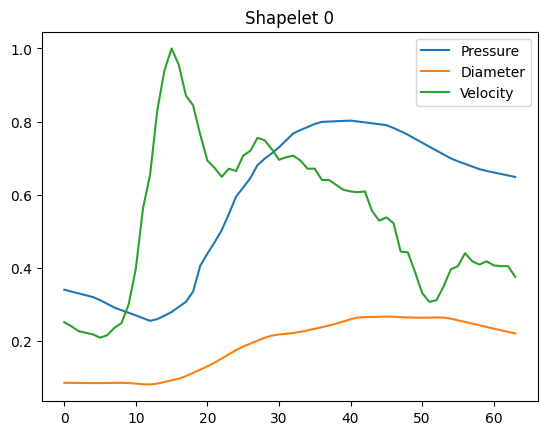

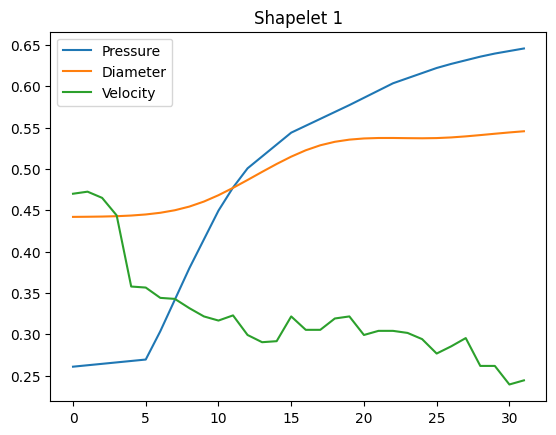

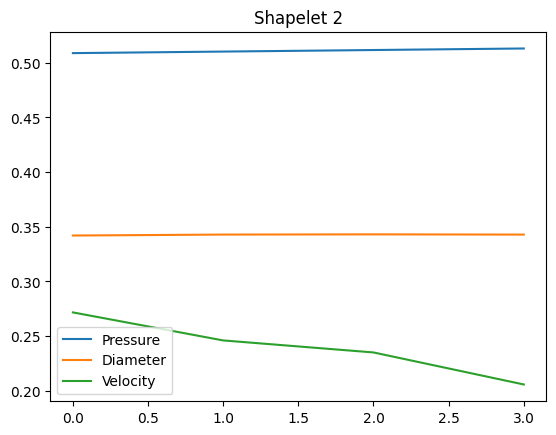

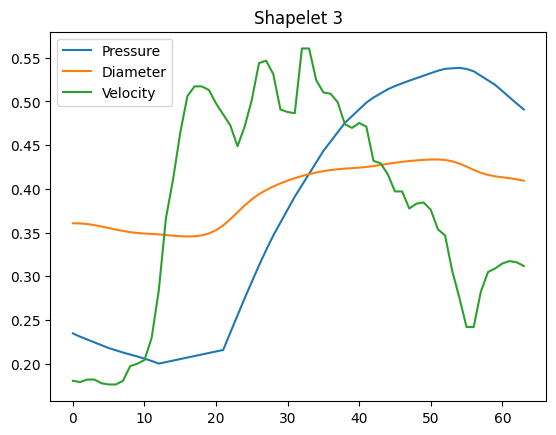

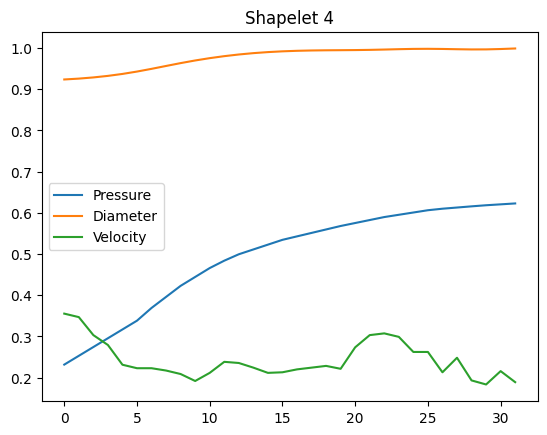

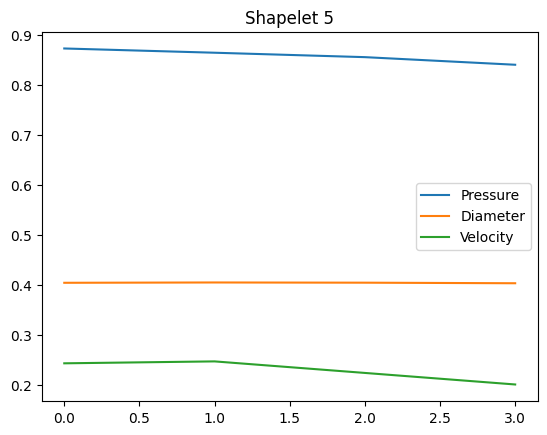

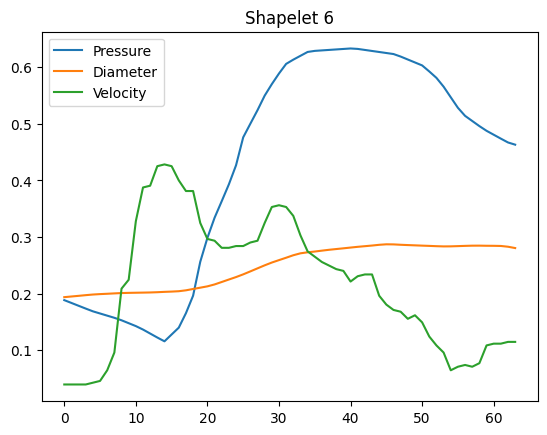

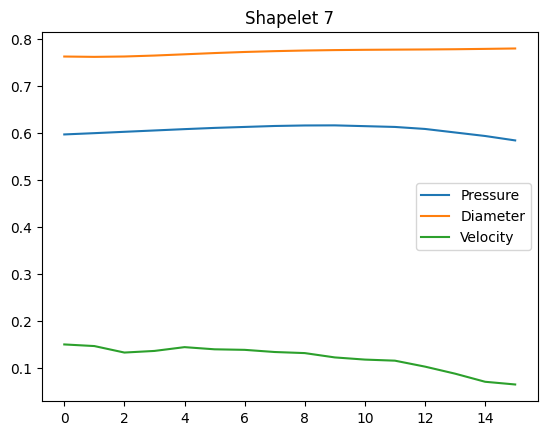

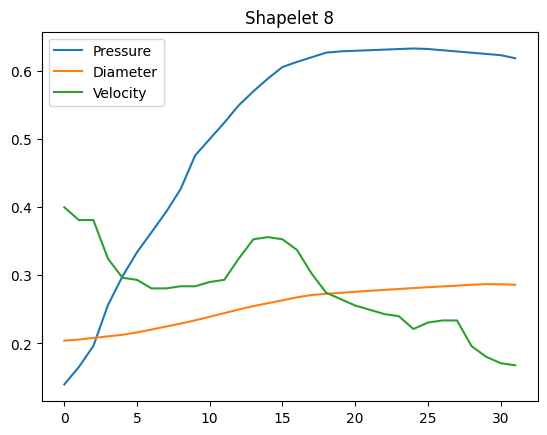

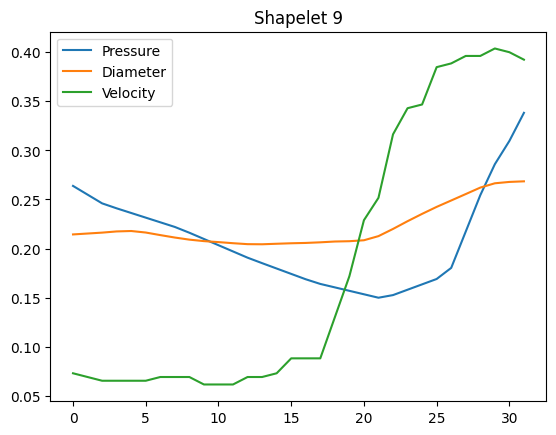

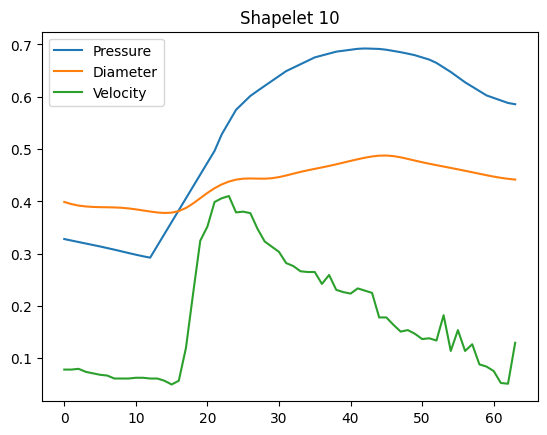

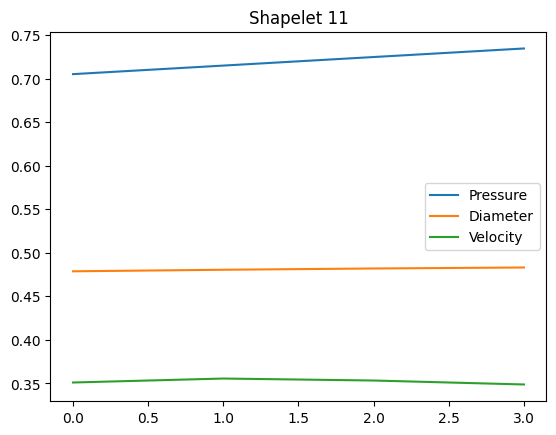

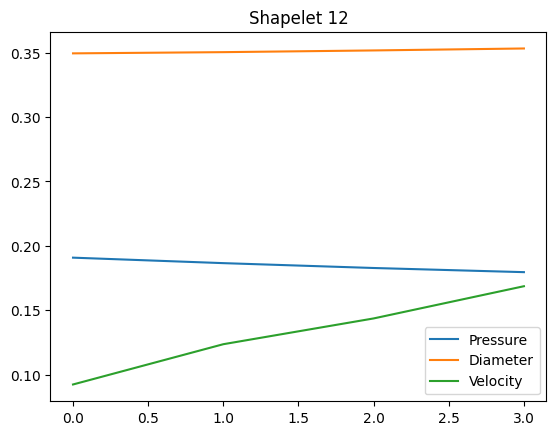

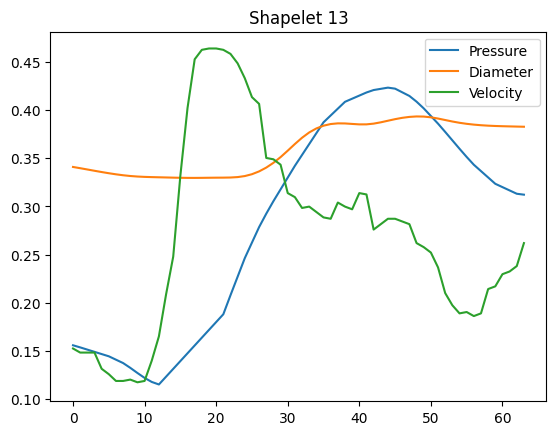

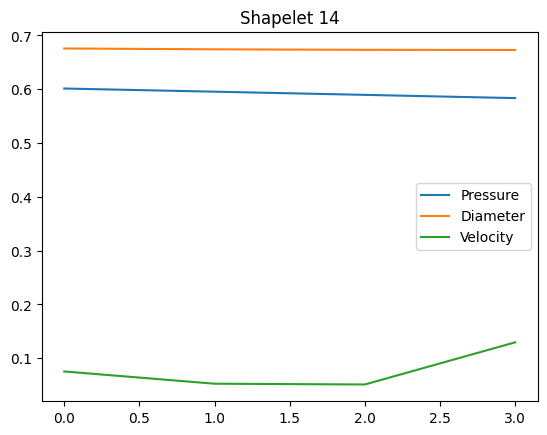

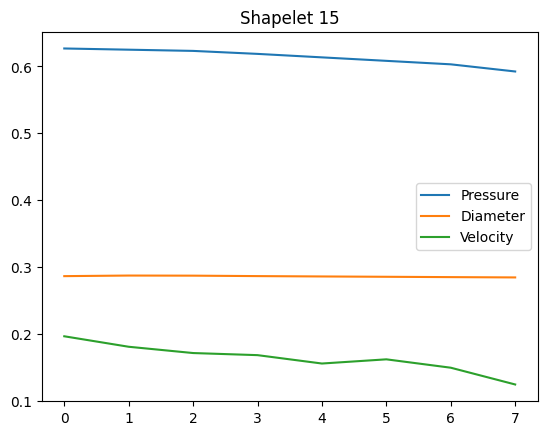

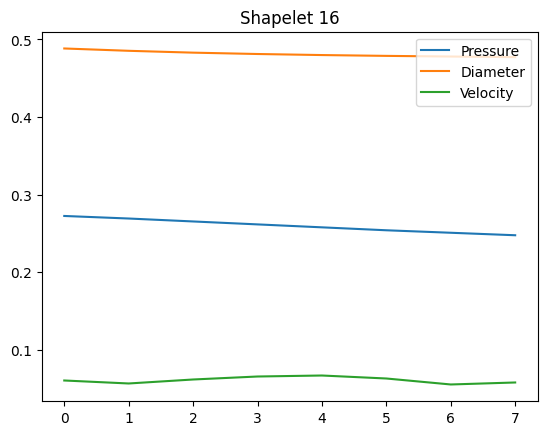

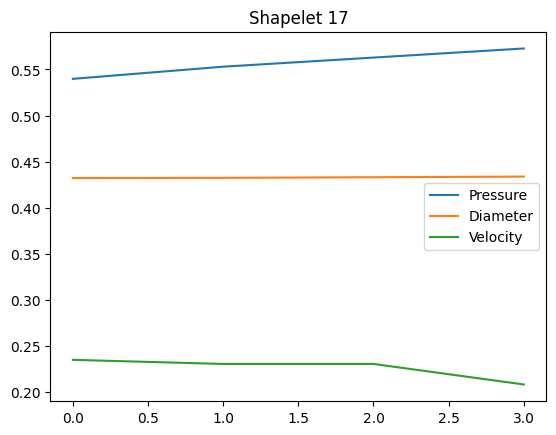

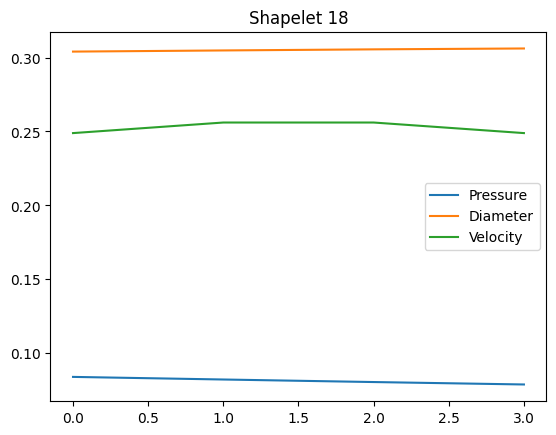

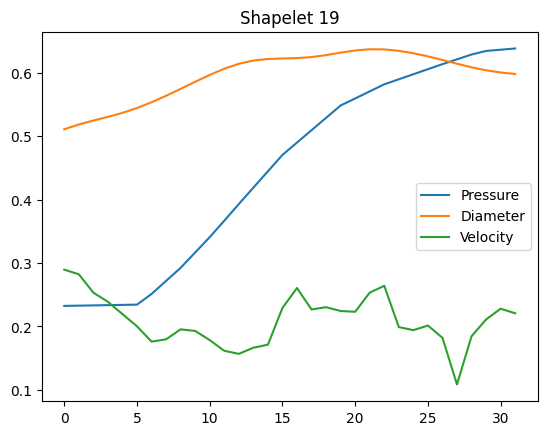

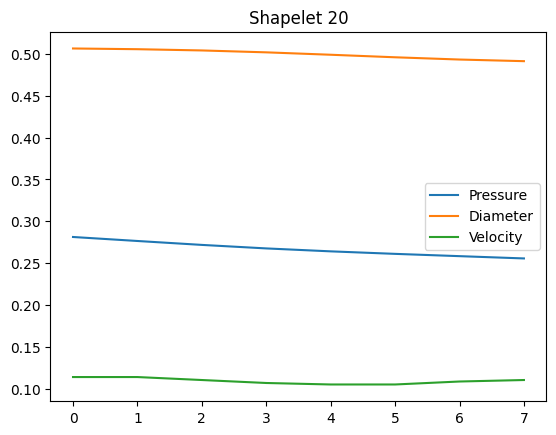

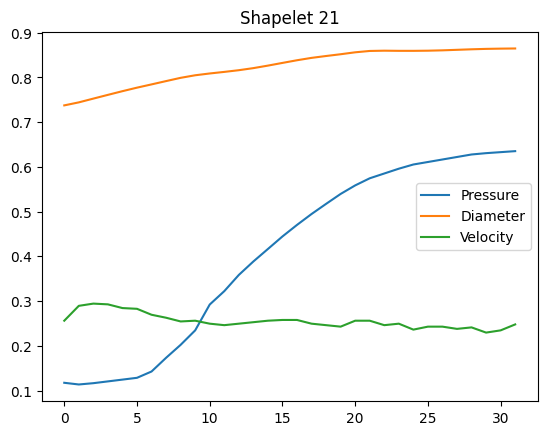

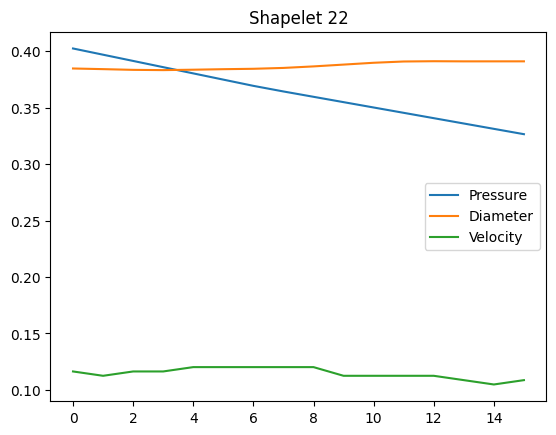

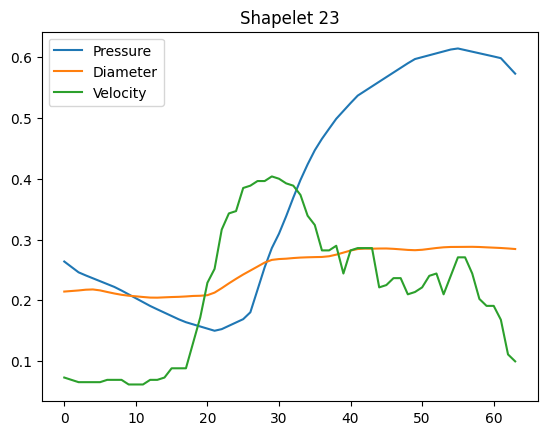

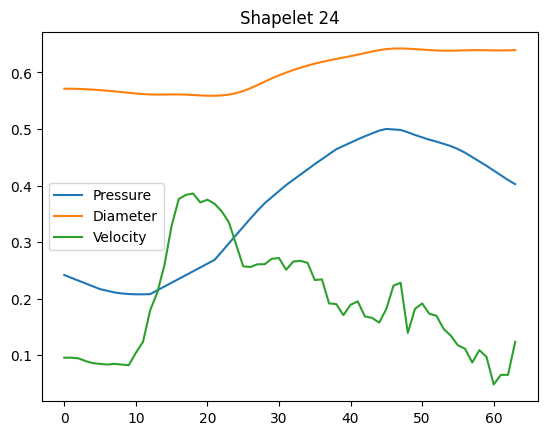

In [ ]:
import matplotlib.pyplot as plt

# for i, shp in enumerate(shapelets[:5]):
#     for d in range(shp.shape[0]):
#         plt.plot(shp[d], label=f'Dim {d}')
#     plt.title(f"Shapelet {i}")
#     plt.legend()
#     plt.show()
import matplotlib.pyplot as plt

# Define mapping for dimension labels
dim_labels = {0: 'Pressure', 1: 'Diameter', 2: 'Velocity'}

for i, shp in enumerate(shapelets[:25]):
    for d in range(shp.shape[0]):
        label = dim_labels.get(d, f'Dim {d}')  # fallback in case d > 2
        plt.plot(shp[d], label=label)
    plt.title(f"Shapelet {i}")
    plt.legend()
    plt.show()



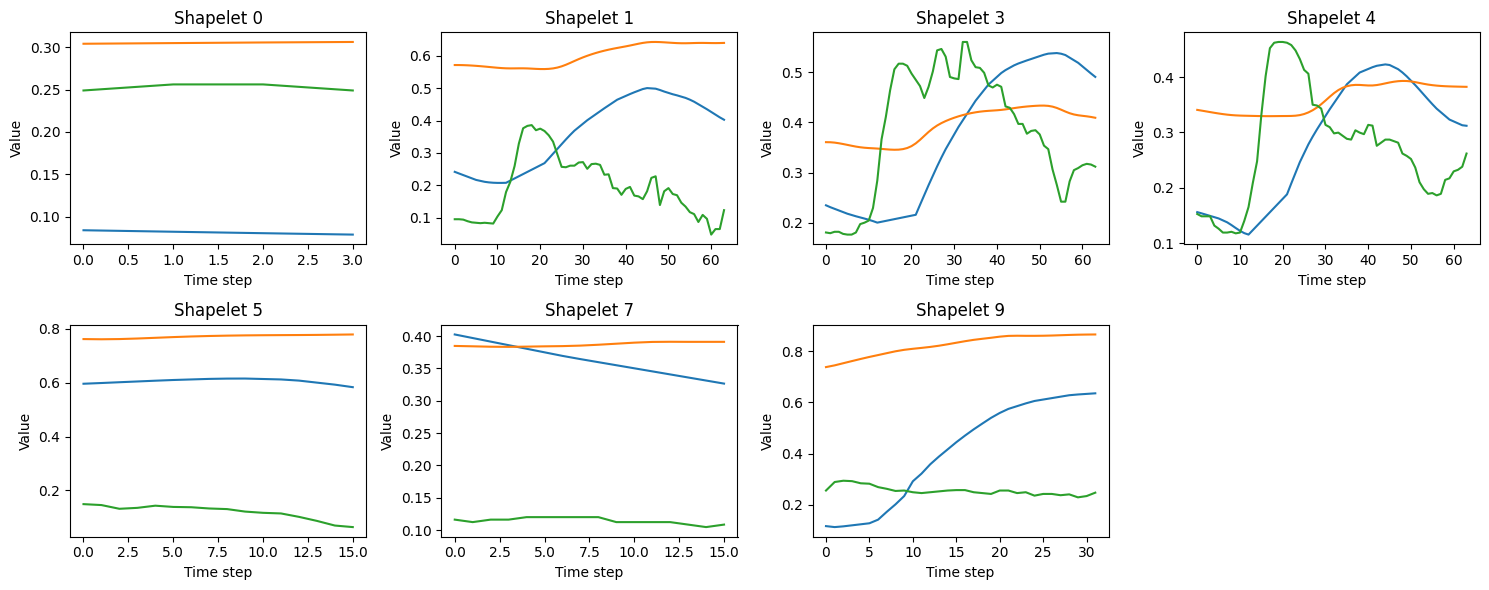

In [ ]:
import matplotlib.pyplot as plt

# older code  selected_indices = [18, 24, 3, 13, 7, 22, 21]
selected_indices = [18, 24, 3, 13, 7, 22, 21]
n_plots = len(selected_indices)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6))
axes = axes.flatten()
index = 0
# older code lists_ = [0,1,3,4,5,7,9]
lists_ = [0,1,3,4,5,7,9]
for ax_idx, shapelet_index in enumerate(selected_indices):

    ax = axes[ax_idx]
    shp = shapelets[shapelet_index]
    for d in range(shp.shape[0]):
        ax.plot(shp[d])  # time on X, values on Y (standard)
    ax.set_title(f"Shapelet {lists_[index]}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")
    index+=1

for j in range(len(selected_indices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()



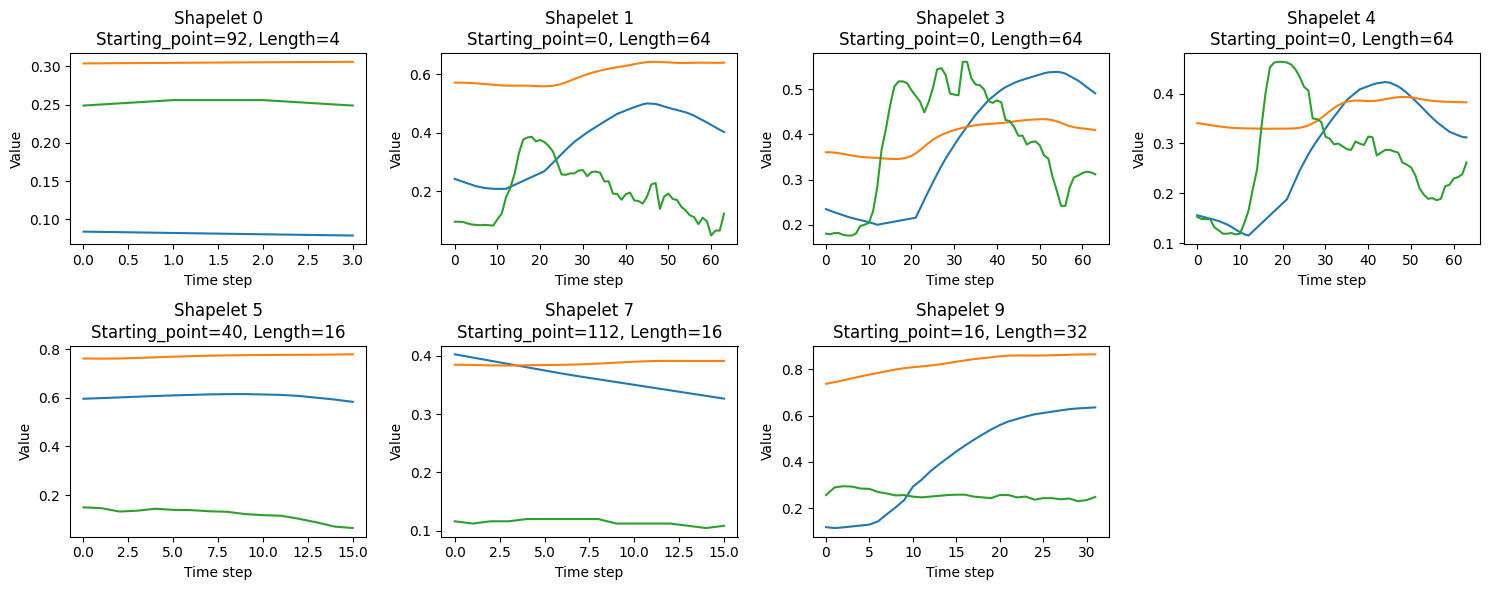

In [ ]:
import matplotlib.pyplot as plt

selected_indices = [18, 24, 3, 13, 7, 22, 21]
n_plots = len(selected_indices)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

# Example metadata (replace with your actual data)
start_times = {18: 92, 24: 0, 3: 0, 13: 0, 7: 40, 22: 112, 21: 16}
seq_lengths = {18: 4, 24: 64, 3: 64, 13: 64, 7: 16, 22: 16, 21: 32}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6))
axes = axes.flatten()
index = 0
lists_ = [0,1,3,4,5,7,9]
for ax_idx, shapelet_index in enumerate(selected_indices):
    ax = axes[ax_idx]
    shp = shapelets[shapelet_index]
    for d in range(shp.shape[0]):
        ax.plot(shp[d])
    st = start_times[shapelet_index]
    sl = seq_lengths[shapelet_index]
    ax.set_title(f"Shapelet {lists_[index]}\nStarting_point={st}, Length={sl}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")
    index+=1

for j in range(len(selected_indices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


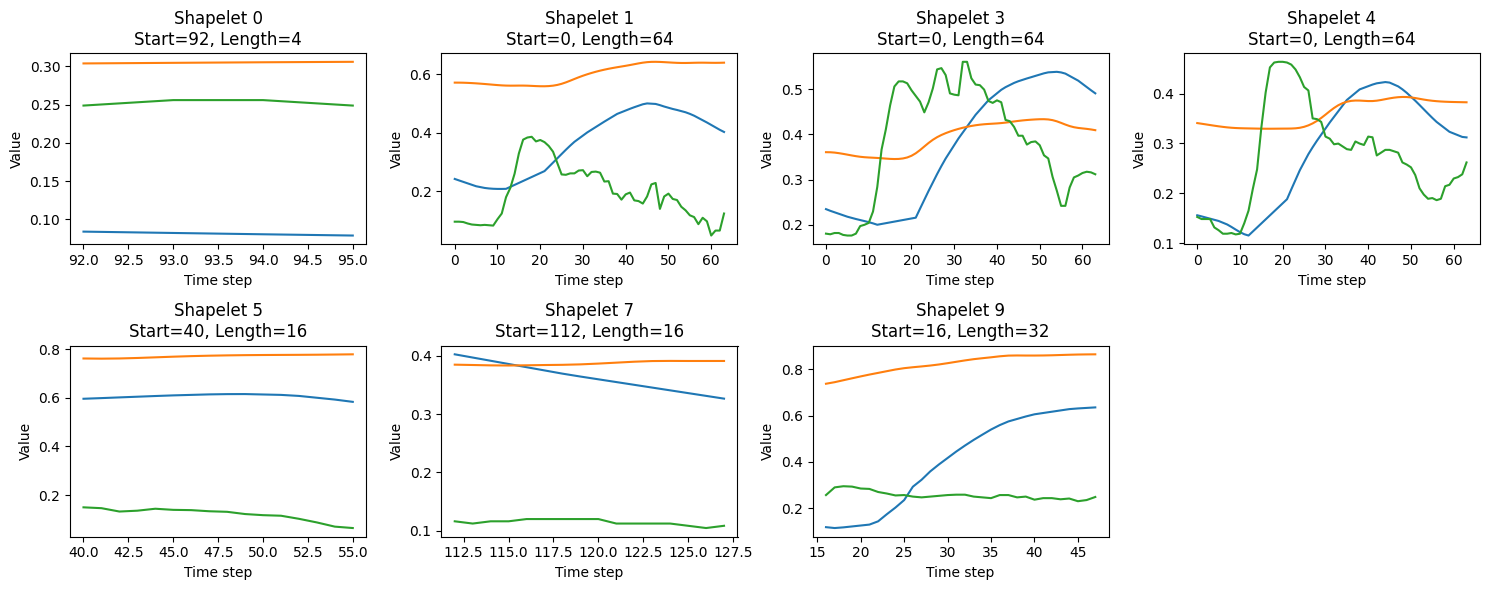

In [ ]:
import matplotlib.pyplot as plt

selected_indices = [18, 24, 3, 13, 7, 22, 21]
n_plots = len(selected_indices)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

# Example metadata (replace with your actual data)
start_times = {18: 92, 24: 0, 3: 0, 13: 0, 7: 40, 22: 112, 21: 16}
seq_lengths = {18: 4, 24: 64, 3: 64, 13: 64, 7: 16, 22: 16, 21: 32}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6))
axes = axes.flatten()
lists_ = [0, 1, 3, 4, 5, 7, 9]

for ax_idx, shapelet_index in enumerate(selected_indices):
    ax = axes[ax_idx]
    shp = shapelets[shapelet_index]

    st = start_times[shapelet_index]
    sl = seq_lengths[shapelet_index]

    # Create an x-axis that starts from the start_time
    x = range(st, st + shp.shape[1])

    # Plot each dimension of the shapelet
    for d in range(shp.shape[0]):
        ax.plot(x, shp[d])

    ax.set_title(f"Shapelet {lists_[ax_idx]}\nStart={st}, Length={sl}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")

# Remove empty subplots
for j in range(len(selected_indices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


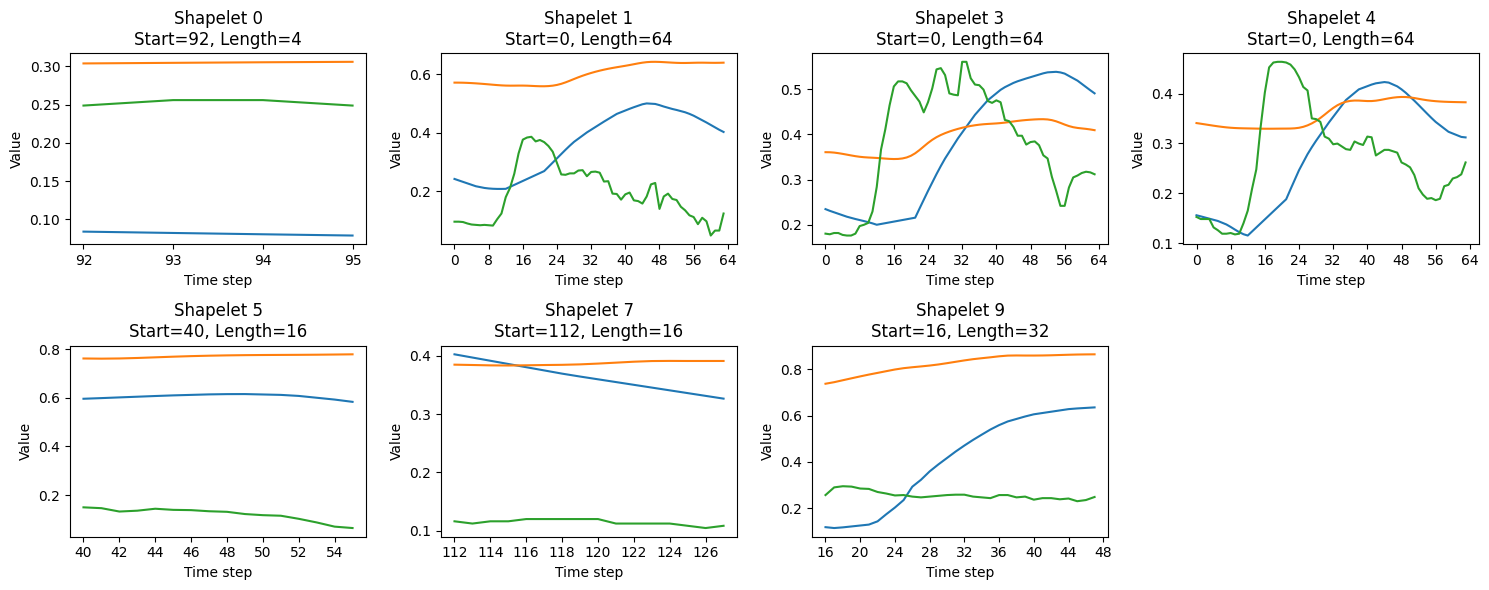

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

selected_indices = [18, 24, 3, 13, 7, 22, 21]
n_plots = len(selected_indices)
n_cols = 4
n_rows = (n_plots + n_cols - 1) // n_cols

start_times = {18: 92, 24: 0, 3: 0, 13: 0, 7: 40, 22: 112, 21: 16}
seq_lengths = {18: 4, 24: 64, 3: 64, 13: 64, 7: 16, 22: 16, 21: 32}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6))
axes = axes.flatten()
lists_ = [0, 1, 3, 4, 5, 7, 9]

for ax_idx, shapelet_index in enumerate(selected_indices):
    ax = axes[ax_idx]
    shp = shapelets[shapelet_index]
    st = start_times[shapelet_index]
    sl = seq_lengths[shapelet_index]

    x = range(st, st + shp.shape[1])
    for d in range(shp.shape[0]):
        ax.plot(x, shp[d])

    ax.set_title(f"Shapelet {lists_[ax_idx]}\nStart={st}, Length={sl}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")

    # ✅ Force integer x-ticks
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

for j in range(len(selected_indices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


#latest

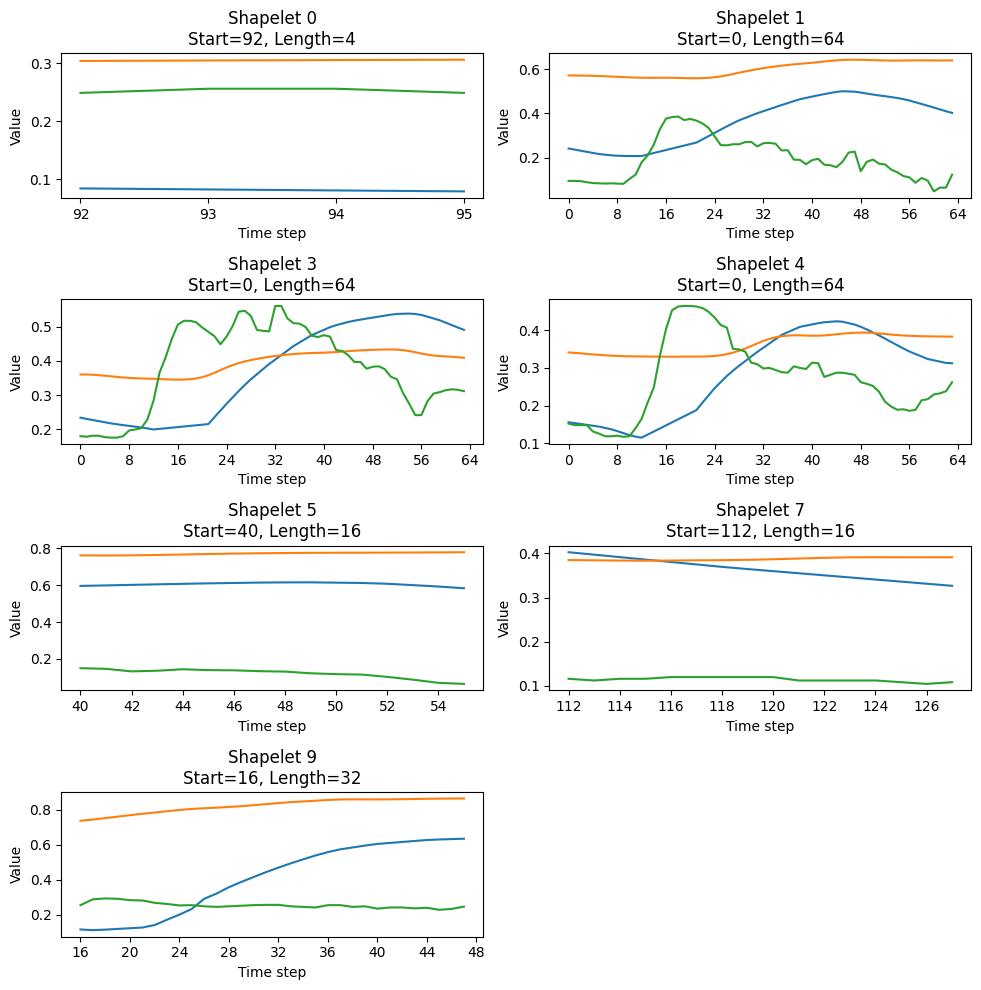

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ✅ Keep only the first 6 shapelets (up to 7, not 9)
selected_indices = [18, 24, 3, 13, 7, 22,21]   # removed 21 (shapelet 9)
lists_ = [0, 1, 3, 4, 5, 7,9]                 # removed the last entry (9)

n_plots = len(selected_indices)
n_cols = 2                                   # ✅ only 2 columns
n_rows = (n_plots + n_cols - 1) // n_cols

start_times = {18: 92, 24: 0, 3: 0, 13: 0, 7: 40, 22: 112, 21: 16}
seq_lengths = {18: 4, 24: 64, 3: 64, 13: 64, 7: 16, 22: 16, 21: 32}

# Adjust figure size for 2-column layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
axes = axes.flatten()

for ax_idx, shapelet_index in enumerate(selected_indices):
    ax = axes[ax_idx]
    shp = shapelets[shapelet_index]
    st = start_times[shapelet_index]
    sl = seq_lengths[shapelet_index]

    x = range(st, st + shp.shape[1])
    for d in range(shp.shape[0]):
        ax.plot(x, shp[d])

    ax.set_title(f"Shapelet {lists_[ax_idx]}\nStart={st}, Length={sl}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")

    # Force integer ticks
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Remove any unused axes
for j in range(len(selected_indices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


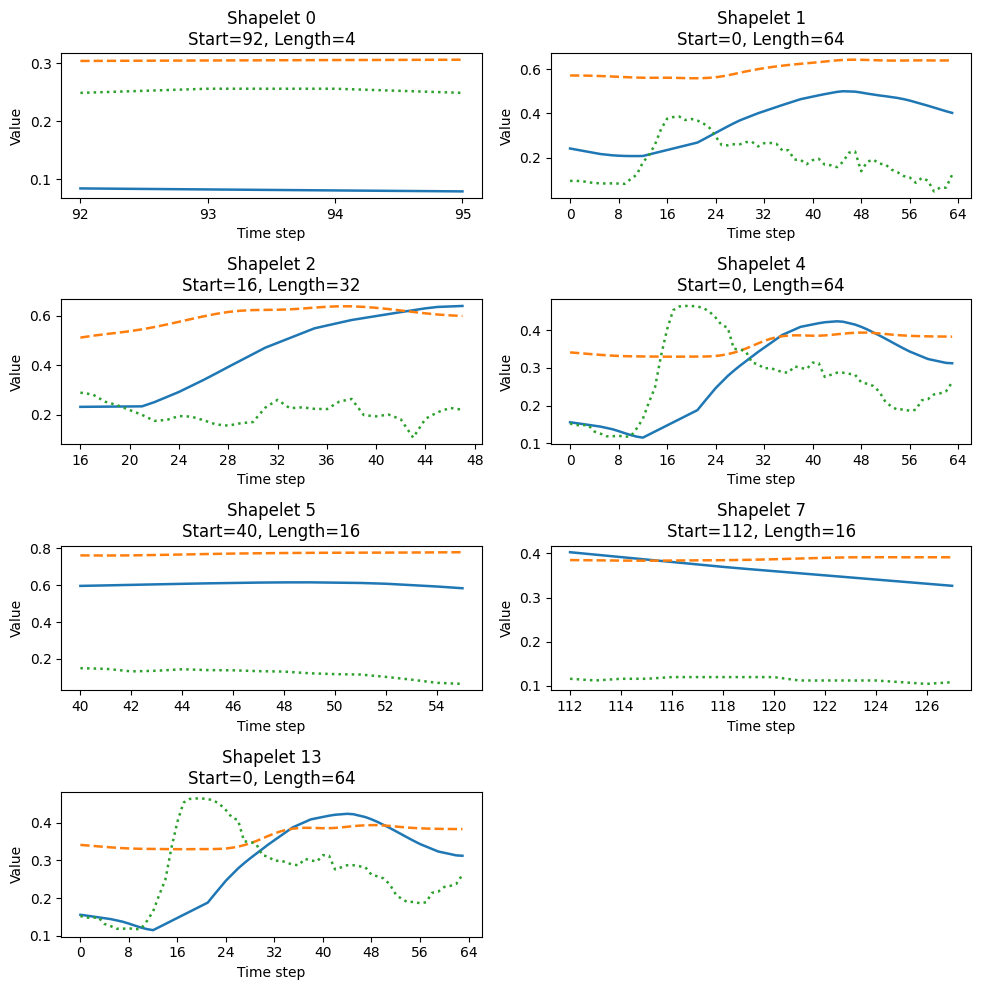

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Only up to Shapelet 7
selected_indices = [18, 24, 19, 13, 7, 22,13]
lists_ = [0, 1, 2, 4, 5, 7,13]

n_plots = len(selected_indices)
n_cols = 2  # ✅ Two plots per row
n_rows = (n_plots + n_cols - 1) // n_cols

start_times = {18: 92, 24: 0, 19: 16, 13: 0, 7: 40, 22: 112, 23: 0}
seq_lengths = {18: 4, 24: 64, 19: 32, 13: 64, 7: 16, 22: 16, 23: 64}

# ✅ Define distinct line styles for accessibility
line_styles = ['-', '--', ':']  # solid, dashed, dotted

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
axes = axes.flatten()

for ax_idx, shapelet_index in enumerate(selected_indices):
    ax = axes[ax_idx]
    shp = shapelets[shapelet_index]
    st = start_times[shapelet_index]
    sl = seq_lengths[shapelet_index]

    x = range(st, st + shp.shape[1])

    for d in range(shp.shape[0]):
        ax.plot(
            x,
            shp[d],
            linestyle=line_styles[d % len(line_styles)],  # ✅ alternate line styles
            linewidth=1.8
        )

    ax.set_title(f"Shapelet {lists_[ax_idx]}\nStart={st}, Length={sl}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")

    # Force integer ticks
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Remove unused axes
for j in range(len(selected_indices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
# ✅ Save at ultra-high resolution (e.g., 1200 dpi)
fig.savefig("/content/drive/MyDrive/Colab Notebooks/shapelet_grid.tiff", dpi=1200, bbox_inches='tight')
plt.show()


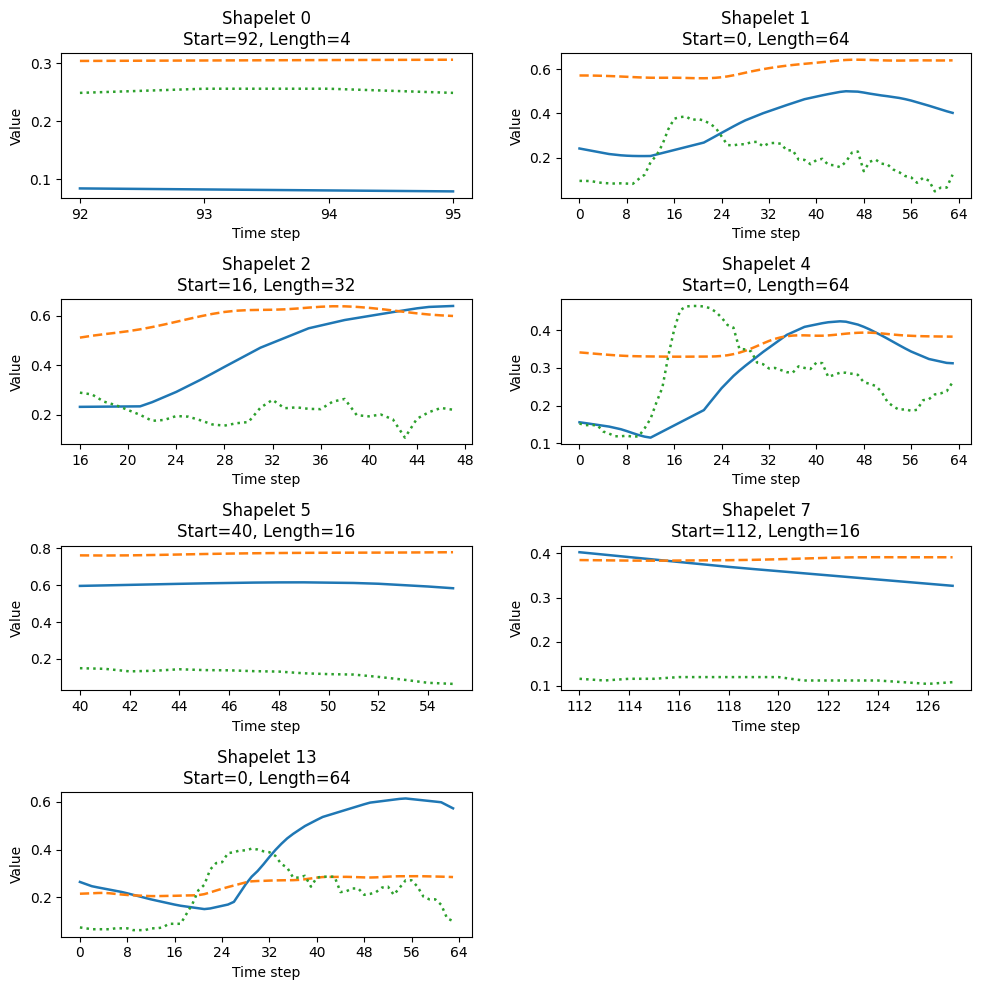

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Only up to Shapelet 7
selected_indices = [18, 24, 19, 13, 7,22, 23]
lists_ = [0, 1, 2, 4, 5,7, 13]

n_plots = len(selected_indices)
n_cols = 2  # ✅ Two plots per row
n_rows = (n_plots + n_cols - 1) // n_cols

start_times = {18: 92, 24: 0, 19: 16, 13: 0, 7: 40, 22: 112, 23: 0}
seq_lengths = {18: 4, 24: 64, 19: 32, 13: 64, 7: 16, 22: 16, 23: 64}

# ✅ Define distinct line styles for accessibility
line_styles = ['-', '--', ':']  # solid, dashed, dotted

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 10))
axes = axes.flatten()

for ax_idx, shapelet_index in enumerate(selected_indices):
    ax = axes[ax_idx]
    shp = shapelets[shapelet_index]
    st = start_times[shapelet_index]
    sl = seq_lengths[shapelet_index]

    x = range(st, st + shp.shape[1])

    for d in range(shp.shape[0]):
        ax.plot(
            x,
            shp[d],
            linestyle=line_styles[d % len(line_styles)],  # ✅ alternate line styles
            linewidth=1.8
        )

    ax.set_title(f"Shapelet {lists_[ax_idx]}\nStart={st}, Length={sl}")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Value")

    # Force integer ticks
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Remove unused axes
for j in range(len(selected_indices), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(w_pad=2.5)
# ✅ Save at ultra-high resolution (e.g., 1200 dpi)
fig.savefig("/content/drive/MyDrive/Colab Notebooks/shapelet_grid.tiff", dpi=1200, bbox_inches='tight')
plt.show()

In [ ]:
# import pandas as pd

# selected_indices = [18, 24, 3, 13, 7, 22, 21]

# # Example metadata (if you want to include info in sheet names)
# start_times = {18: 92, 24: 0, 3: 0, 13: 0, 7: 40, 22: 112, 21: 16}
# seq_lengths = {18: 4, 24: 64, 3: 64, 13: 64, 7: 16, 22: 16, 21: 32}

# # Create an Excel writer
# with pd.ExcelWriter("selected_shapelets.xlsx") as writer:
#     for idx in selected_indices:
#         shp = shapelets[idx]
#         n_dims, length = shp.shape

#         # Create DataFrame for this shapelet
#         df = pd.DataFrame(shp,
#                           index=[f"Dim_{i+1}" for i in range(n_dims)],
#                           columns=[f"t_{t}" for t in range(length)])

#         # Optional metadata
#         start = start_times.get(idx, "NA")
#         length = seq_lengths.get(idx, shp.shape[1])

#         # Sheet name (Excel max 31 chars)
#         sheet_name = f"shp{idx}_len{length}"

#         # Save to its own sheet
#         df.to_excel(writer, sheet_name=sheet_name)

# print("✅ Saved selected shapelets to 'selected_shapelets.xlsx'")
import pandas as pd

selected_indices = [18, 24, 3, 13, 7, 22, 21]

start_times = {18: 92, 24: 0, 3: 0, 13: 0, 7: 40, 22: 112, 21: 16}
seq_lengths = {18: 4, 24: 64, 3: 64, 13: 64, 7: 16, 22: 16, 21: 32}

with pd.ExcelWriter("selected_shapelets_transposed.xlsx") as writer:
    for idx in selected_indices:
        shp = shapelets[idx]
        n_dims, length = shp.shape

        # --- Transpose so rows = time points, columns = dimensions ---
        df = pd.DataFrame(shp.T,
                          columns=[f"Dim_{i+1}" for i in range(n_dims)],
                          index=[f"t_{t}" for t in range(length)])

        start = start_times.get(idx, "NA")
        length = seq_lengths.get(idx, shp.shape[1])

        sheet_name = f"shp{idx}_len{length}"
        df.to_excel(writer, sheet_name=sheet_name)

print("✅ Saved transposed shapelets to 'selected_shapelets_transposed.xlsx'")


✅ Saved transposed shapelets to 'selected_shapelets_transposed.xlsx'


In [ ]:
!ls -lh /content/selected_shapelets_transposed.xlsx


-rw-r--r-- 1 root root 20K Oct 13 02:01 /content/selected_shapelets_transposed.xlsx


In [ ]:
from google.colab import files
files.download("/content/selected_shapelets_transposed.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Compute the RandomShapeltTransform that can take multi-dimensional inputs and use multi-dimensional shapelets

In [ ]:
pip install  aeon

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 33.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.2
    Uninstalling scipy-1.16.2:
      Successfully uninstalled scipy-1.16.2


In [ ]:
import aeon

In [ ]:

from aeon.transformations.collection.shapelet_based import RandomShapeletTransform
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
help(aeon.transformations.collection.shapelet_based.RandomShapeletTransform())

Help on RandomShapeletTransform in module aeon.transformations.collection.shapelet_based._shapelet_transform object:

class RandomShapeletTransform(aeon.transformations.collection.base.BaseCollectionTransformer)
 |  RandomShapeletTransform(n_shapelet_samples: int = 10000, max_shapelets: Optional[int] = None, min_shapelet_length: int = 3, max_shapelet_length: Optional[int] = None, remove_self_similar: bool = True, time_limit_in_minutes: float = 0.0, contract_max_n_shapelet_samples: float = inf, n_jobs: int = 1, parallel_backend=None, batch_size: Optional[int] = 100, random_state: Optional[int] = None) -> None
 |  
 |  Random Shapelet Transform.
 |  
 |  Implementation of the binary shapelet transform along the lines of [1]_, [2]_, with
 |  randomly extracted shapelets. A shapelet is a subsequence from the train set. The
 |  transform finds a set of shapelets that are good at separating the classes based on
 |  the distances between shapelets and whole series. The distance between a shap

In [ ]:
# instantiate the RandomShapeletTransform Object
rst = RandomShapeletTransform(n_shapelet_samples=100,max_shapelets=1000, random_state=42)
# Fit the transformer object to the data
rst.fit_transform(X,y)
# Transform the test data using the fitted transformer
x_rst = rst.transform(X)
x_rst.shape

(150, 100)

## Use mRMR algorithm to find get only relevant parameters

In [ ]:
pip install mrmr_selection

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import mrmr
from mrmr import mrmr_classif

# Assuming x_rst and y are already defined

# Perform mRMR feature selection
selected_features = mrmr_classif(pd.DataFrame(x_rst), pd.Series(y), K=10)  # Select top 10 features

# Print the selected features
print("Selected features:", selected_features)

# Create a new DataFrame with only the selected features
x_rst_selected = pd.DataFrame(x_rst)[selected_features]

NameError: name 'x_rst' is not defined

In [ ]:
# train_test classification
#classify x_rst to train, validation and test split
from sklearn.model_selection import train_test_split
x_train_rst, x_test, y_train_rst, y_test = train_test_split(
    x_rst_selected, y, test_size=0.2, random_state=42, stratify=y
)

# DO mRMR on my multivariate shapelets too.

In [ ]:
from mrmr import mrmr_classif
# Perform mRMR feature selection
selected_features_2 = mrmr_classif(pd.DataFrame(features), pd.Series(y), K=10)  # Select top 10 features
# Print the selected features
print("Selected features:", selected_features_2)

# Create a new DataFrame with only the selected features
x_selected_2 = pd.DataFrame(features)[selected_features_2]

100%|██████████| 10/10 [00:00<00:00, 48.08it/s]

Selected features: [np.int64(18), np.int64(15), np.int64(24), np.int64(14), np.int64(22), np.int64(13), np.int64(3), np.int64(6), np.int64(16), np.int64(0)]


In [ ]:
# see glimpse of both x_rst_selected and x_selected_2
print(x_selected_2.head())


         18        15         24        14        22         13         3   \
0  0.915901  1.714865  10.304113  0.591340  4.963898  11.357985  11.088048   
1  1.484936  2.160030  10.322552  0.777241  5.749399  11.316775  11.048651   
2  1.635360  1.369124  11.369895  0.781667  5.538870  12.237775  11.813740   
3  1.085546  1.445700   7.306402  0.699793  2.169438   6.885348   6.667806   
4  0.332368  1.635663   8.317612  1.151197  2.867491   9.410653   9.002474   

         6         16        0   
0  5.447154  2.639020  7.494519  
1  5.490132  2.760411  7.523318  
2  7.942410  1.929394  9.080917  
3  6.015714  1.864438  4.952675  
4  4.674972  2.905215  6.541313  


In [ ]:
print(x_rst_selected.head())

NameError: name 'x_rst_selected' is not defined

### train-test classify my shapelets

In [ ]:
# train_test classification
from sklearn.model_selection import train_test_split
x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(
    x_selected_2, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# compare the two types of train_test data I have on a random forest model
# use x_train_rst, x_test, y_train_rst, y_test = train_test_split(x_rst_selected, y, test_size=0.2, random_state=42, stratify=y) to train a random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_classifier.fit(x_train_rst, y_train_rst)
y_pred_rst = random_forest_classifier.predict(x_test)
#wvaluate metrics
accuracy_rst = accuracy_score(y_test, y_pred_rst)
print(f"Accuracy: {accuracy_rst}")
print(classification_report(y_test, y_pred_rst))


NameError: name 'x_train_rst' is not defined

In [ ]:
# use x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(x_selected_2, y, test_size=0.2, random_state=42, stratify=y) to train a random forest model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
random_forest_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_classifier.fit(x_train_2, y_train_2)
y_pred_2 = random_forest_classifier.predict(x_test_2)
#wvaluate metrics
accuracy_2 = accuracy_score(y_test_2, y_pred_2)
print(f"Accuracy: {accuracy_2}")
print(classification_report(y_test_2, y_pred_2))

Accuracy: 0.7666666666666667
              precision    recall  f1-score   support

           0       0.83      0.87      0.85        23
           1       0.50      0.43      0.46         7

    accuracy                           0.77        30
   macro avg       0.67      0.65      0.66        30
weighted avg       0.76      0.77      0.76        30



In [ ]:
# Find also AUC
from sklearn.metrics import roc_auc_score
# auc_rst = roc_auc_score(y_test, y_pred_rst)
# print(f"AUC: {auc_rst}")
auc_2 = roc_auc_score(y_test_2, y_pred_2)
print(f"AUC: {auc_2}")


AUC: 0.6490683229813664


In [ ]:
# Add y as column named 'rsast__label' to the x_selected_2
x_selected_2['__label'] = y

In [ ]:
print(x_selected_2['__label'])

0      1
1      1
2      1
3      1
4      1
      ..
145    0
146    0
147    0
148    0
149    0
Name: __label, Length: 150, dtype: int64


In [ ]:
x_selected_2.shape

(150, 11)

In [ ]:
x_selected_2.head()

,24,25,4,21,7,20,17,2,3,10
0,2.531698e-15,1.005882,1.895406,2.378755e-14,1.897150e-15,5.447154,2.465095e-15,2.954290,0.379253,1.007471
1,4.806125e-15,0.773973,2.785158,2.952400e-14,3.094716e-15,5.490132,5.207408e-16,2.858019,0.091550,1.048507
2,5.376277e-15,0.385777,2.388832,2.043293e-14,2.560743e-15,7.942410,4.004505e-15,1.921738,0.737631,0.210940
3,2.286089e-15,0.371054,2.076077,5.250275e-14,1.874272e-15,6.015714,3.240634e-15,1.394373,0.066194,0.457820
4,7.829237e-15,0.855072,2.584288,2.513914e-14,9.656388e-15,4.674972,6.123361e-15,1.878255,0.659787,0.796861


In [ ]:
# save the x_selected_2 as csv
x_selected_2.to_csv('/content/drive/MyDrive/A_RESEARCH_TRAINING/SHAPELETS/x_selected_2.csv', index=False)

In [ ]:
import numpy as np

# Example distances
dists_example = np.array([0.1, 0.5, 0.2, 0.8, 0.3, 0.6, 0.9, 0.4, 0.7, 1.0,
                          1.1, 1.5, 1.2, 1.8, 1.3, 1.6, 1.9, 1.4, 1.7, 2.0])

n_bins = 20

# Calculate bin edges
bins_example = np.histogram_bin_edges(dists_example, bins=n_bins)

print("Example distances:", dists_example)
print("Number of bins:", n_bins)
print("Bin edges:", bins_example)
print("Number of bin edges:", len(bins_example))

Example distances: [0.1 0.5 0.2 0.8 0.3 0.6 0.9 0.4 0.7 1.  1.1 1.5 1.2 1.8 1.3 1.6 1.9 1.4
 1.7 2. ]
Number of bins: 20
Bin edges: [0.1   0.195 0.29  0.385 0.48  0.575 0.67  0.765 0.86  0.955 1.05  1.145
 1.24  1.335 1.43  1.525 1.62  1.715 1.81  1.905 2.   ]
Number of bin edges: 21
